# Accoppiamento di un fotodiodo con un LED in corrente continua

A cura di Giovanni N. D'Aloisio, matricola 494722, A.A. 2022-23.

## Introduzione

Esponendo un semiconduttore alla radiazione elettromagnetica, se l’energia del singolo fotone $E = hν = hc/ \lambda$ è maggiore del gap $E_g$ del semiconduttore,  è possibile che il fotone venga assorbito dando origine ad una coppia elettrone-lacuna. Questo significa un elettrone in più in banda di conduzione ed una lacuna in più in banda di valenza. Si ha quindi una variazione nel numero di portatori (sia elettroni che lacune, simultaneamente) che partecipano sia ai moti diffusivi che di deriva (in presenza di un campo elettrico).

La risposta di un diodo illuminato (o fotodiodo) è descritta dalla legge:

$$I = I_0 (e^{\frac{qV}{kT}}- 1)-I_\text{ph}$$

Dove:  
- $q=1.602 \cdot 10^{-19}C$ è la carica dell'elettrone,
- $k = 1.380 \cdot 10^{-23} J/K$ è la costante di bolzmann,
- $T$ è temperatura in kelvin dell'ambiente di lavoro,
- $V$ è il potenziale ai capi del diodo,
- $I$ è la corrente nel diodo,
- $I_0$ è la corrente di saturazione del diodo,
- $I_\text{ph}$ è la corrente prodotta dall'esposizione della radiazione elettromagnetica.

Risulta $I_\text{ph}$ proporzionale al numero di fotoni assorbiti.

## Scopo dell'esperienza
Gli scopi dell'esperienza sono:

1.   Studiare la risposta del fotodiodo in corrente e in tensione, con l'eventuale aggiunta di una resistenza di carico;
2.   Valutare la caratterisca volt-amperometrica in funzione della resistenza.



## Strumentazione

Per raggiungere gli obiettivi della prova, si dispone di:
+ un LED;
+ un fotodiodo;
+ 2 tester (amperometro e voltmetro);
+ un alimentatore in corrente continua;
+ una breadboard;
+ più resistori, con valori diversi;
+ un trimmer.

### Prima e seconda esperienza

Si noti che nella prima esperienza la resistenza di carico R è assente.

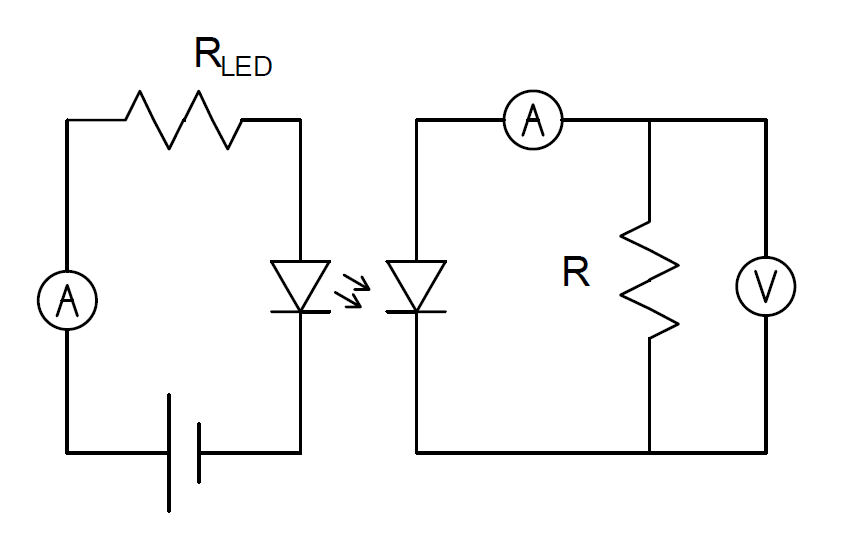

### Terza esperienza

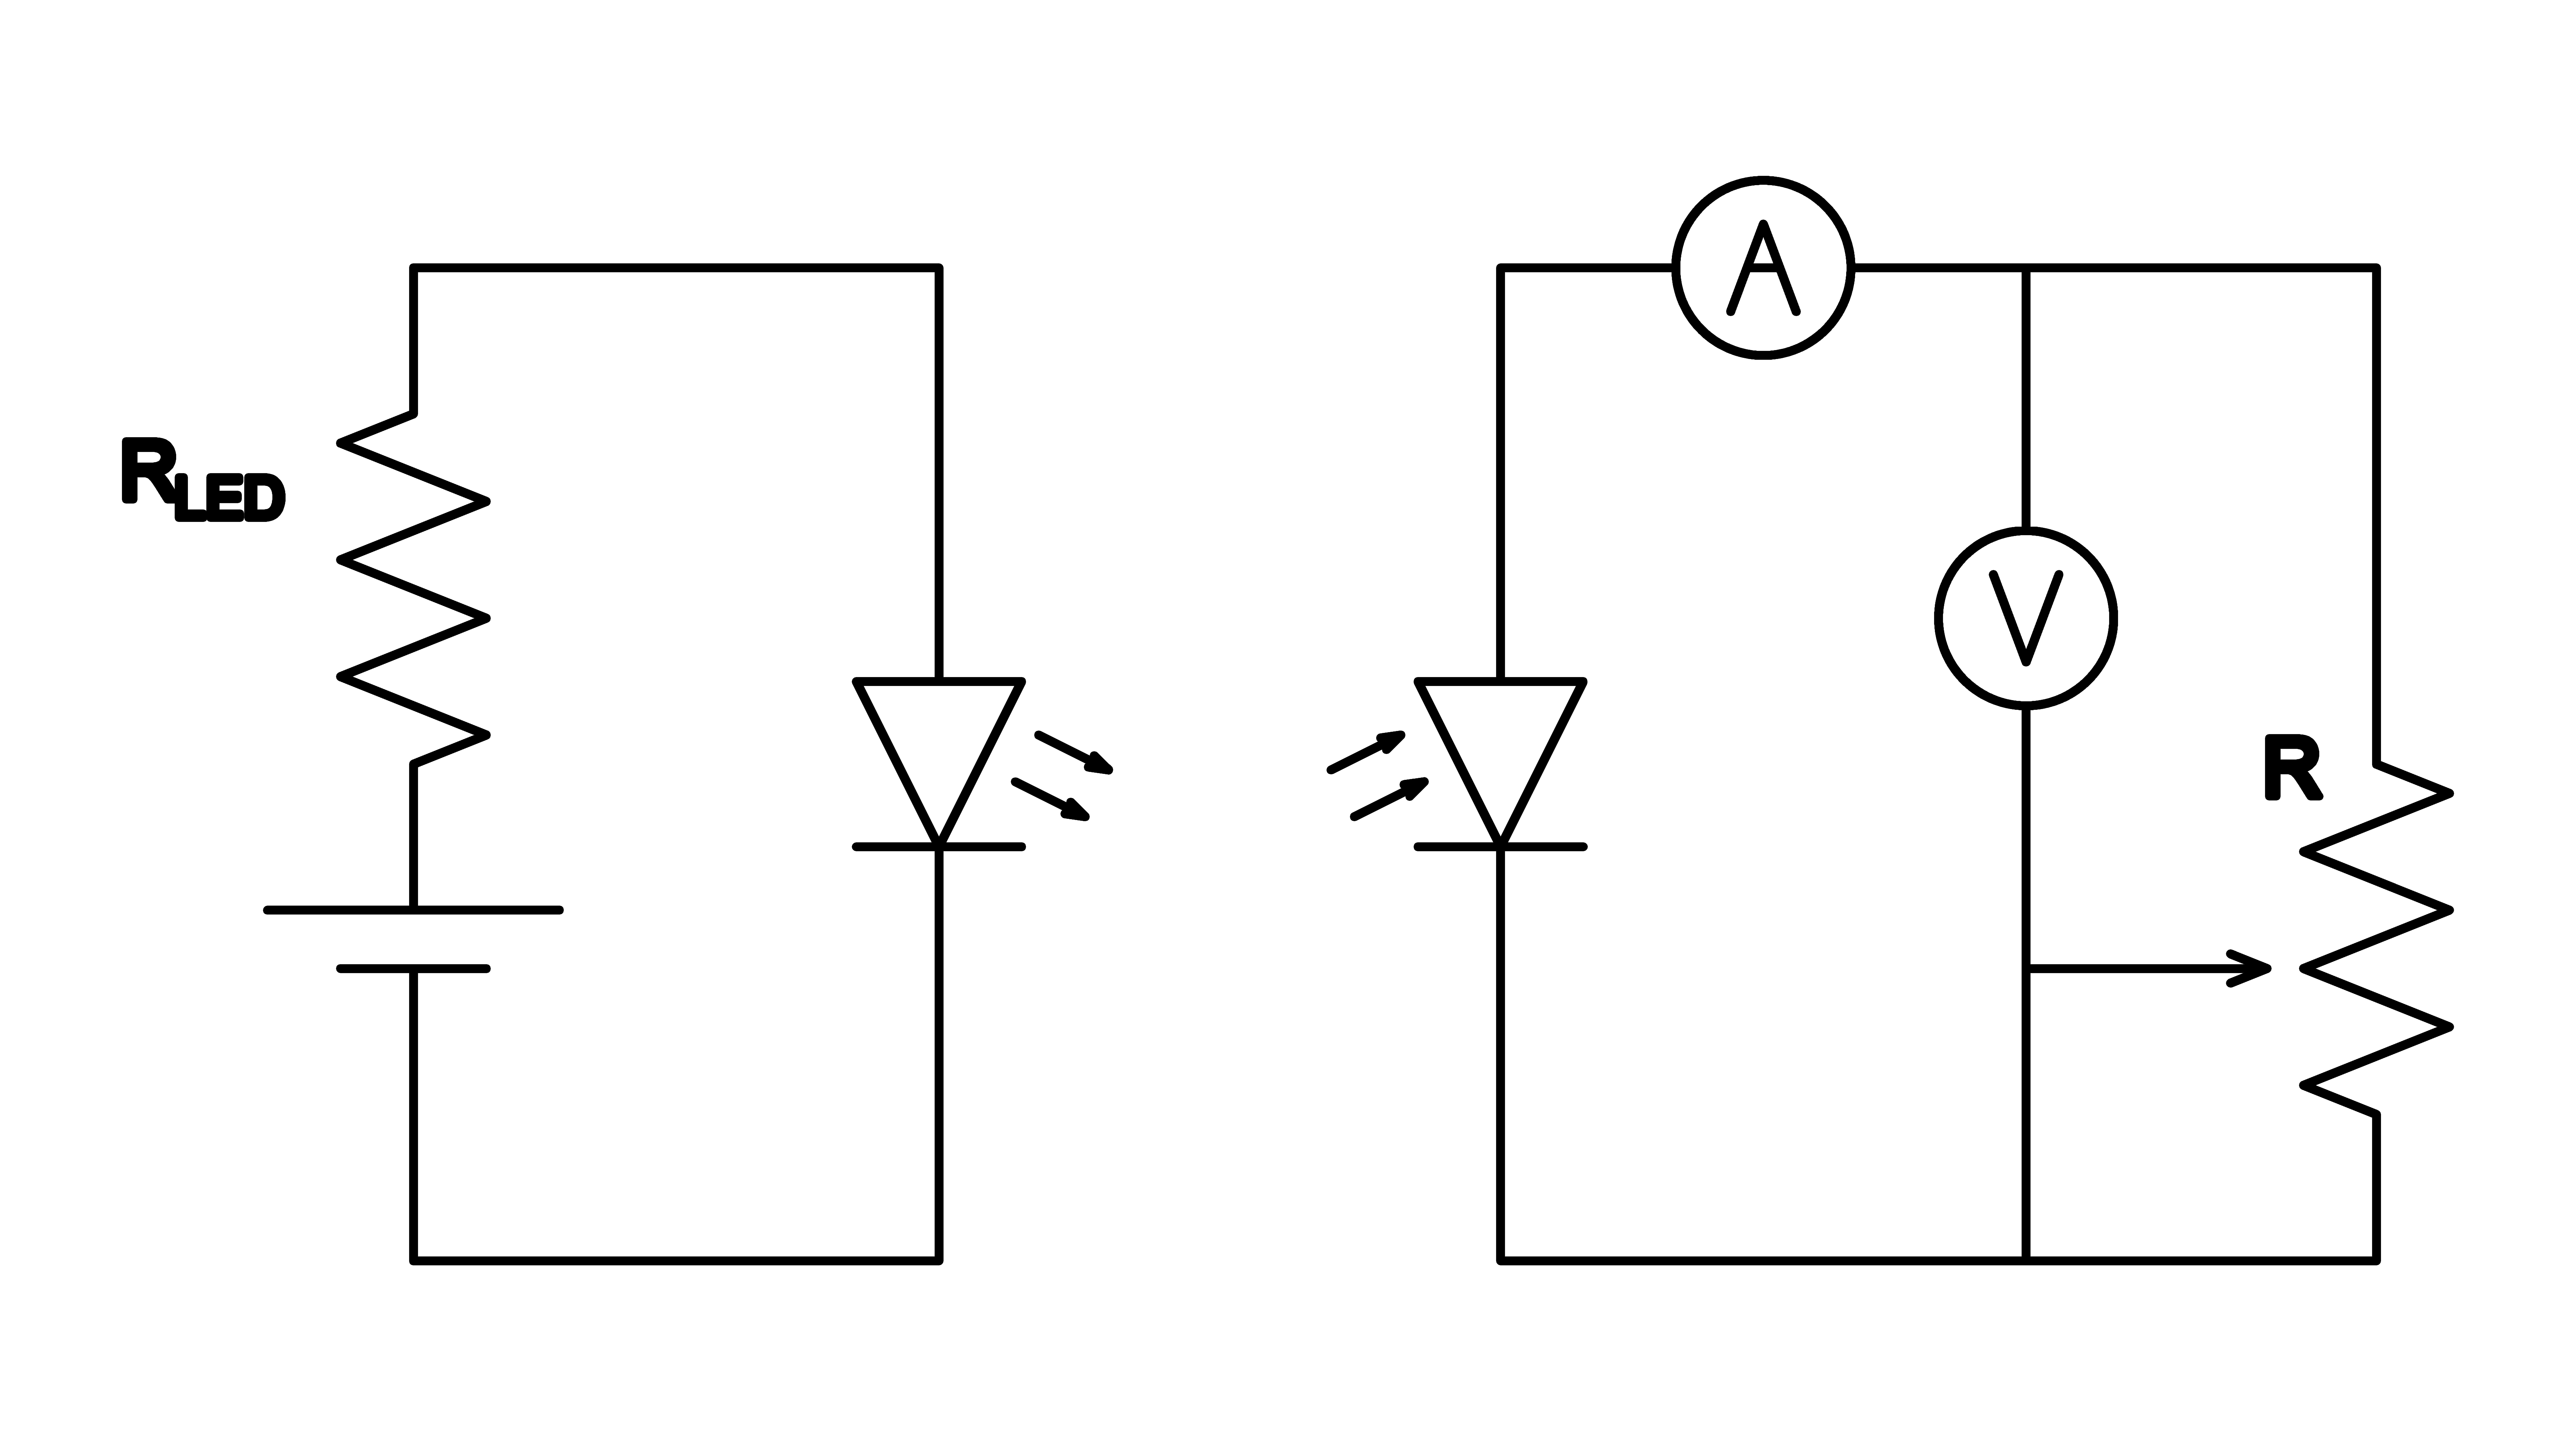

## Procedura sperimentale

L'esperimento consiste in 3 sotto-esperimenti distinti.

### Parte 1 - Misura della risposta in corrente e in tensione

Connettendo un amperometro ai capi del fotodiodo si ottiene un cortocircuito, in cui $I = −I_\text{ph} ∝ I_\text{LED}$. In tali condizioni, si misura la corrente nel fotodiodo in funzione della corrente di alimentazione del
LED.

Connettendo invece un voltmetro si ottiene un circuito sostanzialmente aperto, per cui:

$$I_0 (e^{qV/kT}-1) = I_\text{ph}∝ I_\text{LED}$$

$$\Rightarrow V ≈ \ln I_\text{ph} ∝ \ln I_\text{LED} + k$$

Con k costante. In questo modo si misura la tensione sul fotodiodo, in funzione della corrente di alimentazione del LED.

### Parte 2 - Risposta in tensione su una resistenza di carico

Inserendo una resistenza in serie con il fotodiodo (e misurando la
tensione $V_R$ ai suoi capi), devono essere soddisfatte le relazioni:

$$I_D = I_0 (e^{qV_D/kT}-1)-I_\text{ph} \quad \quad 
I_R=-V_D/R \quad \quad 
I_D=I_R$$

$$\Rightarrow I_{ph} = I_0 (e^{qV_D/kT}-1)+\frac{V_D}{R}∝P_\text{em}$$

con $P_\text{em}$ intensità della radiazione. La verifica può essere eseguita con un fit dei dati catturati da misure di tensione e corrente.

### Parte 3 - Caratteristica I-V in funzione della resistenza

Fissando un valore definito per l’intensità di illuminazione $P_\text{em}$, mediante l'applicazione di una costante corrente di alimentazione per il LED, e quindi per $I_\text{ph}$, e variando la resistenza $R$, si misurano le coppie di valori $I_D − V_D$.

Presi tali valori, possibilmente per più valori di $P_\text{em}$, si riportano in grafico le coppie di valori $I − V$ trovate, più i valori di potenza in funzione della resistenza, che a sua volta può essere misurata con un tester, calcolata come rapporto di tensione e corrente, o nota a priori.

## Importazione e analisi dei dati sperimentali
Di seguito, i dati raccolti vengono importati nel notebook per l'analisi.

Visitare la pagina [GitHub](https://github.com/nikitodos/UniPV_Physics_Lab_3/tree/main/01_LED_PD_CC_COUPLING) per visualizzare i dati sotto forma di tabelle.

### Parte 1 - Misura della risposta in corrente e in tensione del fotodiodo, senza resistenza di carico

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
from scipy import constants as scc
import matplotlib.pyplot as plt  
import pandas as pd

# Definisci costanti fisiche utili

electron_charge = scc.e
Boltzmann = scc.Boltzmann
temperature = 300          # kelvin

# Definisci funzione di fit per prova con circuito chiuso
def funzioneampere(I_LED, beta, fondo):
  I_misurata = fondo + (beta * I_LED)
  return I_misurata

# Definisci funzione di fit per prova con circuito aperto - Non fittabile per divergenza del logaritmo
def funzionevolt(I_LED, A, beta, B):
  V_FD = A * np.log(I_LED * beta) + B
  return V_FD 

# Importa i dati in unità del Sistema Internazionale

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/01_LED_PD_CC_COUPLING/Part1/PD_AMPERE.CSV'
data = pd.read_csv(filename)
I_LED=data['Corrente LED (mA)'].to_numpy()*1e-3
I_PD=data['Corrente PD (uA)'].to_numpy()*1e-6

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/01_LED_PD_CC_COUPLING/Part1/PD_VOLT.CSV'
data = pd.read_csv(filename)
I_LED_1=data['corrente LED (mA)'].to_numpy()*1e-3
V_PD_1=data['tensione PD (mV)'].to_numpy()*1e-3

# Fit dei dati sperimentali

ndata=len(I_PD)
# min, max = [beta_min, fondo_min], [beta_max, fondo_max]
# min, max = [0.000000001,0],[1000,1000]
# bounds = [min, max]

popt, pcov=sop.curve_fit(funzioneampere, I_LED, I_PD)  # no bounds to your dreams :)
beta_fit = popt[0]
fondo_fit  = popt[1]
sigma0 = np.sqrt(ndata*np.diag(pcov))

# Stampa dati da regressione lineare

print(' ')

print('Parametri di fit dei dati, a resistenza di carico assente')

print('Dati fit a circuito chiuso:   beta_fit = (', np.format_float_scientific(beta_fit,precision=2), '±', np.format_float_scientific(sigma0[0],precision=1), ')')
print('                              Ib_fit   = (', np.format_float_scientific(fondo_fit,precision=2), '±', np.format_float_scientific(sigma0[1],precision=1), ') A')

print(' ')

 
Parametri di fit dei dati, a resistenza di carico assente
Dati fit a circuito chiuso:   beta_fit = ( 1.37e-03 ± 1.1e-04 )
                              Ib_fit   = ( 3.87e-07 ± 1.3e-06 ) A
 


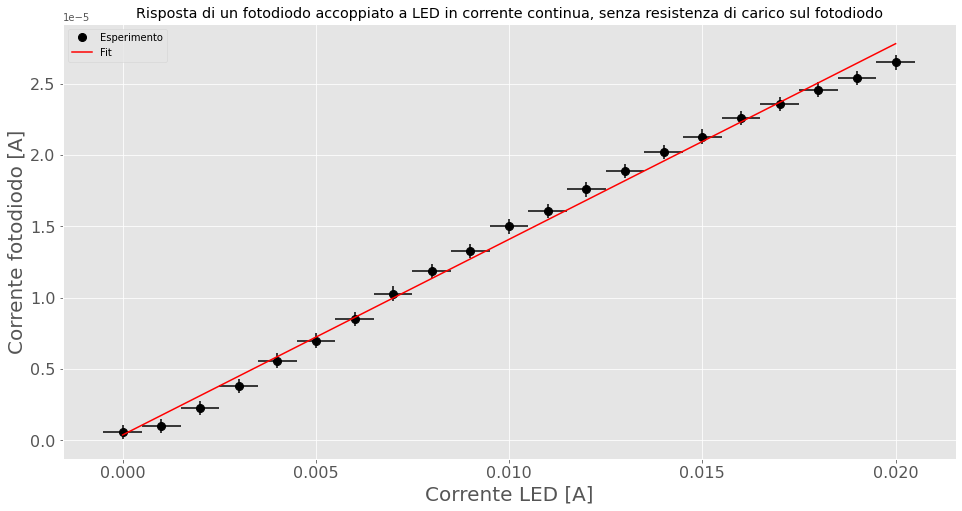

In [ ]:
# Plot dati fittati e reali su scala lineare, con misure di corrente

plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a LED in corrente continua, senza resistenza di carico sul fotodiodo')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Corrente LED [A]', fontsize=20)
plt.ylabel('Corrente fotodiodo [A]', fontsize=20)
plt.grid(True)
plt.plot(I_LED,I_PD,'o',markersize=8,label="Esperimento",color='black')
y=funzioneampere(I_LED,beta_fit,fondo_fit)
plt.errorbar(I_LED,I_PD,xerr=0.0005, yerr=0.0000005,color='black',linestyle='None')
plt.plot(I_LED,y,label="Fit",color='red')
plt.style.use("ggplot")
plt.legend()

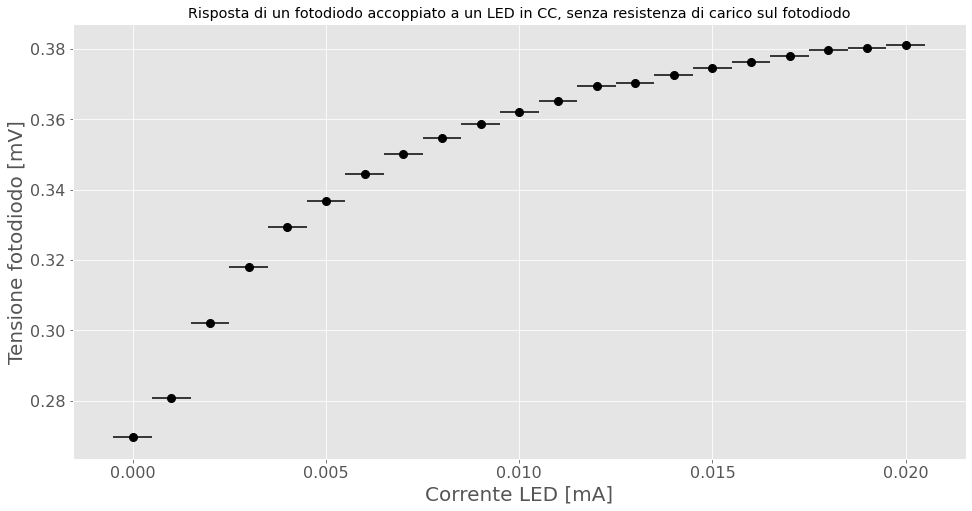

In [ ]:
# Plot dati fittati e reali su scala lineare, con misure di tensione

plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a un LED in CC, senza resistenza di carico sul fotodiodo')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Corrente LED [mA]', fontsize=20)
plt.ylabel('Tensione fotodiodo [mV]', fontsize=20)
plt.errorbar(I_LED_1,V_PD_1,xerr=0.0005, yerr=0.0005,color='black',linestyle='None')
plt.grid(True)
plt.plot(I_LED_1,V_PD_1,'o',markersize=8,color='black')
plt.style.use("ggplot")

### Parte 2 - Risposta in tensione del fotodiodo con una resistenza di carico

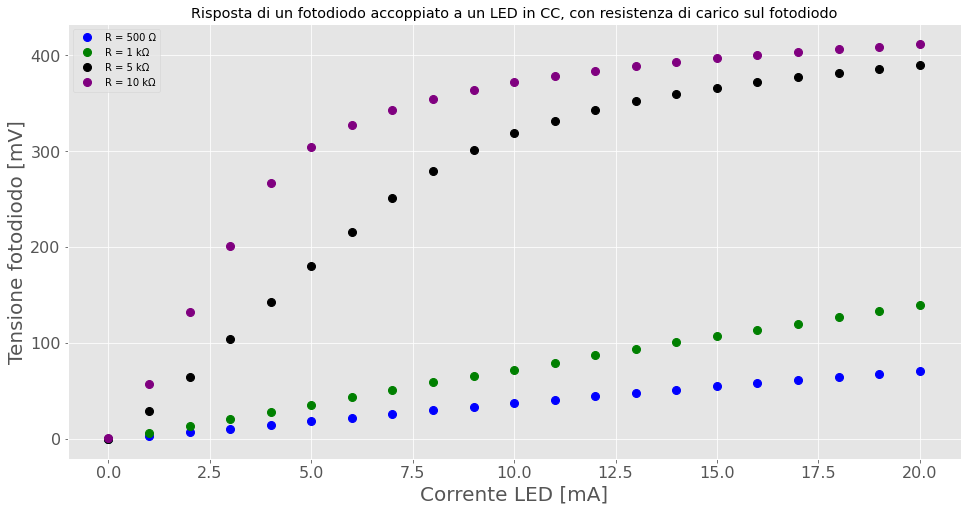

In [ ]:

# Importa i dati con R = 500, 1000, 5000, 10000

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/01_LED_PD_CC_COUPLING/Part2/NEW_DATA.CSV'
data = pd.read_csv(filename)

# Dati in mA

I_LED_R=data['Corrente LED'].to_numpy()*1000

# Dati in mV

V_PH_500=data['500'].to_numpy()*1000
V_PH_1000=data['1000'].to_numpy()*1000
V_PH_5000=data['5000'].to_numpy()*1000
V_PH_10000=data['10000'].to_numpy()*1000

print(' ')

# Plot dati fittati e reali su scala lineare

plt.figure(figsize=[16,8])
plt.title('Risposta di un fotodiodo accoppiato a un LED in CC, con resistenza di carico sul fotodiodo')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Corrente LED [mA]', fontsize=20)
plt.ylabel('Tensione fotodiodo [mV]', fontsize=20)
plt.grid(True)
plt.errorbar(I_LED_R,V_PH_500,yerr=0.5,xerr=0.005,linestyle='',color='blue')
plt.plot(I_LED_R,V_PH_500,'o',markersize=8,color="blue", label="R = 500 Ω")
plt.errorbar(I_LED_R,V_PH_1000,yerr=0.5,xerr=0.005,linestyle='',color='green')
plt.plot(I_LED_R,V_PH_1000,'o',markersize=8,color="green", label="R = 1 kΩ")
plt.errorbar(I_LED_R,V_PH_5000,yerr=0.5,xerr=0.005,linestyle='',color='black')
plt.plot(I_LED_R,V_PH_5000,'o',markersize=8,color="black", label="R = 5 kΩ")
plt.errorbar(I_LED_R,V_PH_10000,yerr=0.5,xerr=0.005,linestyle='',color='purple')
plt.plot(I_LED_R,V_PH_10000,'o',markersize=8,color="purple", label="R = 10 kΩ")
plt.style.use("ggplot")
plt.legend()


### Parte 3 - Caratteristica I-V del fotodiodo in funzione della resistenza

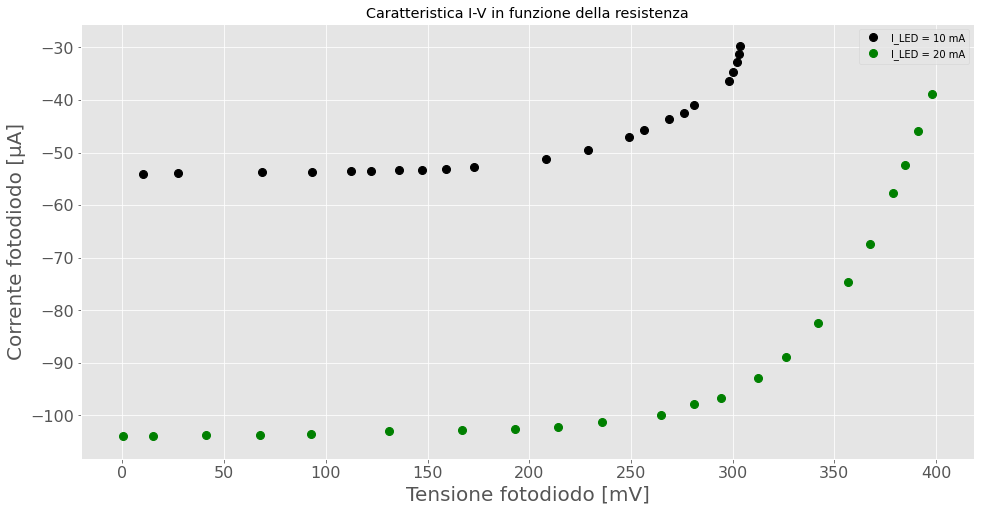

In [ ]:

# Importa i dati per plot I-V in unità S.I.

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/01_LED_PD_CC_COUPLING/PART3.CSV'
data = pd.read_csv(filename)

# I_LED = 10 mA

I_PH_LED_10=data['microA@I_LED=10mA'].to_numpy()*1e-6
V_PH_LED_10=data['mV@I_LED=10mA'].to_numpy()*1e-3

# I_LED = 20 mA

I_PH_LED_20=data['microA@I_LED=20mA'].to_numpy()*1e-6
V_PH_LED_20=data['mV@I_LED=20mA'].to_numpy()*1e-3

# Plot dati fittati e reali su scala lineare

plt.figure(figsize=[16,8])
plt.title('Caratteristica I-V in funzione della resistenza')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Tensione fotodiodo [mV]', fontsize=20)
plt.ylabel('Corrente fotodiodo [µA]', fontsize=20)
plt.grid(True)
plt.errorbar(V_PH_LED_10*1000,I_PH_LED_10*1000000,yerr=0.5,xerr=0.5,linestyle='',color='black')
plt.plot(V_PH_LED_10*1000,I_PH_LED_10*1000000,'o',markersize=8,color="black", label="I_LED = 10 mA")
plt.errorbar(V_PH_LED_20*1000,I_PH_LED_20*1000000,yerr=0.5,xerr=0.5,linestyle='',color='green')
plt.plot(V_PH_LED_20*1000,I_PH_LED_20*1000000,'o',markersize=8,color="green", label="I_LED = 20 mA")
plt.style.use("ggplot")
plt.legend()


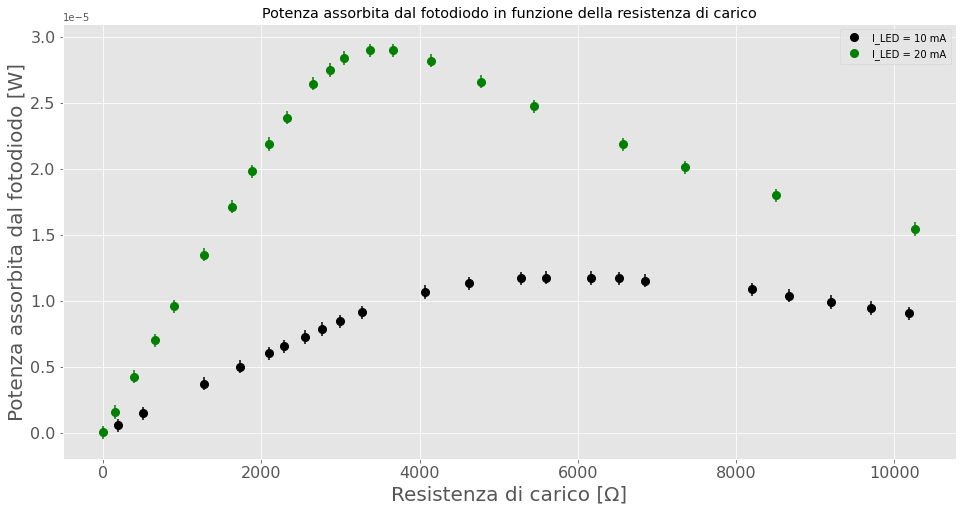

In [ ]:

# Importa i dati per plot P-R in unità S.I.

# I_LED = 10 mA

RESISTANCE_10 = -V_PH_LED_10/I_PH_LED_10
POWER_10 = -I_PH_LED_10*V_PH_LED_10

# I_LED = 20 mA

RESISTANCE_20 = -V_PH_LED_20/I_PH_LED_20
POWER_20 = -I_PH_LED_20*V_PH_LED_20

# Plot dati fittati e reali su scala lineare

plt.figure(figsize=[16,8])
plt.title('Potenza assorbita dal fotodiodo in funzione della resistenza di carico')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Resistenza di carico [Ω]', fontsize=20)
plt.ylabel('Potenza assorbita dal fotodiodo [W]', fontsize=20)
plt.grid(True)
plt.errorbar(RESISTANCE_10,POWER_10,yerr=0.0000005,xerr=0.5,linestyle='',color='black')
plt.plot(RESISTANCE_10,POWER_10,'o',markersize=8,label="I_LED = 10 mA",color='black')
plt.errorbar(RESISTANCE_20,POWER_20,yerr=0.0000005,xerr=0.5,linestyle='',color='green')
plt.plot(RESISTANCE_20,POWER_20,'o',markersize=8,label="I_LED = 20 mA",color='green')
plt.style.use("ggplot")
plt.legend()


## Discussione dei risultati e conclusioni

Dai dati raccolti risulta che la corrente fotogenerata è proporzionale all’intensità del fascio di luce incidente sul fotodiodo, e questa, emessa dal LED, è, a sua volta, proporzionale alla corrente di alimentazione del LED, come previsto dalla teoria. Per ciò che riguarda invece la riposta in tensione, non si è riusciti a sfruttare la funzione di fit per stimare i parametri in quanto la presenza del logaritmo rende difficile la convergenza dell'algoritmo.

Inoltre, per la seconda parte risulta che per valori piccoli di $R$ e di $V_D$ il termine $V_D/R$ (lineare) domina la relazione, in opposizione a quanto si osserva per valori grandi di $R$ (con cui la risposta è dominata dal termine
esponenziale). La prima parte dell'esperienza può essere dunque vista come i due casi limite per $R=0 \ \Omega$  (circuito chiuso) e  $R=∞ \ Ω$  (circuito aperto).

Nella terza parte dell'esperimento, sono stati presi valori di tensione e corrente per due valori fissati di $P_\text{em}$, mediante l'applicazione di una $I_\text{LED}$ costante, e pari a 10 e 20 mA, rispettivamente. Come da previsioni, nella curva della potenza dissipata nel fotodiodo si ottiene un picco marcatamente maggiore in presenza di corrente di alimentazione del LED maggiore.

Per i risultati raggiunti si ritiene che gli scopi della prova sono stati raggiunti con successo.